In [1]:
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor, BlipProcessor, BlipForConditionalGeneration, pipeline
from qwen_vl_utils import process_vision_info
import gradio as gr
import zipfile
import os
import numpy as np
import random
import shutil
import pandas as pd
import cv2
from qwen import read_blue_channel
import yaml
from qwen import read_red_channel, read_green_channel, read_blue_channel, extract_zip_path, generate_random_sample
from langchain.prompts import PromptTemplate
from langchain.chat_models import ChatOpenAI
from langchain.chains import LLMChain
import json

c:\Users\archi\anaconda3\envs\asid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
c:\Users\archi\anaconda3\envs\asid\lib\site-packages\torchvision\transfo

In [2]:
HOME = os.path.expanduser('~') + "\\ecdna-analysis"
config_path = os.path.join(HOME, "config.yaml")

In [3]:
config = open(config_path)
var = yaml.load(config, Loader=yaml.FullLoader)['qwen']
var

{'zipfile_path': 'data\\ecSeg_dataset.zip',
 'test_folder_name': 'test_im',
 'test_extract_folder': 'test_im_images',
 'train_folder_name': 'train_im',
 'train_extract_folder': 'train_im_images',
 'sampled': 'sampled',
 'sample_size': 200}

In [4]:
zip_file_path = os.path.join(HOME, var['zipfile_path'])
test_folder_name = var['test_folder_name']
test_extract_folder = os.path.join(HOME, var['test_extract_folder'])
train_folder_name = var['train_folder_name']
train_extract_folder = os.path.join(HOME, var['train_extract_folder'])

In [5]:
zip_file_path

'C:\\Users\\archi\\ecdna-analysis\\data\\ecSeg_dataset.zip'

In [6]:
extract_zip_path(zip_file_path, train_folder_name, train_extract_folder)
extract_zip_path(zip_file_path, test_folder_name, test_extract_folder)

In [7]:
sample_size = var['sample_size']
input_folder = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
output_folder = os.path.join(HOME, var['sampled'] )

In [8]:
generate_random_sample(input_folder, output_folder, sample_size)

1189


,0
0,1536.tif
1,1342.tif
2,514.tif
3,44.tif
4,2296.tif
...,...
195,662.tif
196,2337.tif
197,41.tif
198,534.tif


In [9]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:07<00:00,  3.65s/it]


In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = model.to(device)
model.get_parameter

cuda


<bound method Module.get_parameter of Qwen2VLForConditionalGeneration(
  (visual): Qwen2VisionTransformerPretrainedModel(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
    )
    (rotary_pos_emb): VisionRotaryEmbedding()
    (blocks): ModuleList(
      (0-31): 32 x Qwen2VLVisionBlock(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): VisionAttention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (mlp): VisionMlp(
          (fc1): Linear(in_features=1280, out_features=5120, bias=True)
          (act): QuickGELUActivation()
          (fc2): Linear(in_features=5120, out_features=1280, bias=True)
        )
      )
    )
    (merger): PatchMerger(
      (ln_q): LayerNorm((1280,), eps=1e-06, element

In [11]:
test_images = os.path.join(test_extract_folder , f'ecSeg_dataset\\{test_folder_name}')
train_images = os.path.join(train_extract_folder , f'ecSeg_dataset\\{train_folder_name}')

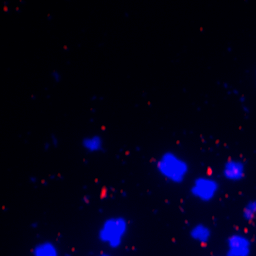

In [12]:
img_num = 589
img_path = os.path.join(test_images, f'{img_num}.tif')
Image.open(img_path)

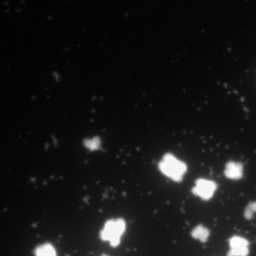

In [13]:
read_blue_channel(img_path)

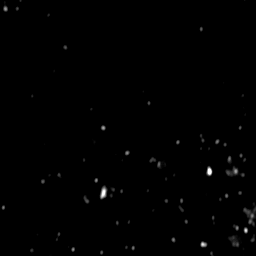

In [14]:
read_red_channel(img_path)

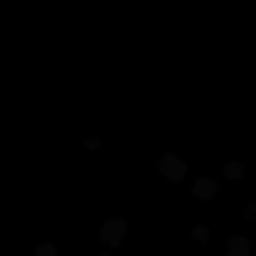

In [15]:
read_green_channel(img_path)

In [ ]:
def get_predictions(root_folder, image, system_message=''):
    """
        This function generates the prediction of the number of nuclei, chromosomes, and ecDNA
        in a cell image.

        Inputs:
            system_message: description specifying the role of the model when making predictions
            root_folder: folder storing all the images (either train_images or test_images)
            image: number of the image followed by .tif extension
        Returns:
            A number representing the count of ecDNA
    """

    prompt = PromptTemplate(
        template = 
        '''
            {system_message}
            How many ecDNA are in the image? Return a single number as the answer.
        '''
    )

    formatted_prompt = prompt.format(system_message=system_message)

    img_path = os.path.join(root_folder, image)
    img = read_red_channel(img_path)

    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image'},
                {'type': 'text', 'text': 'This is an image of a cell with nuclei, chromosomes, and ecDNA.'}
            ]
        },
        {
            'role': 'assistant',
            'content': 'Thank you for the information. How can I assist you today?'
        },


        
        {
            'role': 'user',
            'content': [
                {'type': 'image'},
                {'type': 'text', 'text': 'ecDNA are small round structures shown as circular white structures.'},
                {'type': 'image'},
                {'type': 'text', 'text': formatted_prompt},  
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, add_vision_id=True
    )

    inputs = processor(
        text=[text],
        images=[img, img, img],
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(device)

    generated_ids = model.generate(**inputs, max_new_tokens=120)

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    with open('C:/Users/archi/ecdna-analysis/qwen/output.txt', 'w') as f:
        f.write(output_text)
    
    f.close()

    return output_text

   

In [17]:
train = pd.read_csv('C:/Users/archi/ecdna-analysis/train_images_counts.csv')
print(train.shape)
train.head()

(4760, 4)


,image,num_nuclei,num_chromosomes,num_ecDNA
0,2343.tif,1,0,0
1,2344.tif,2,0,0
2,2345.tif,0,5,0
3,2346.tif,0,18,0
4,2347.tif,1,6,1


In [18]:
test = pd.read_csv('C:/Users/archi/ecdna-analysis/test_images_counts.csv')
print(test.shape)
test.head()

(1189, 4)


,image,num_nuclei,num_chromosomes,num_ecDNA
0,0.tif,2,1,1
1,1.tif,4,1,3
2,10.tif,1,6,2
3,1000.tif,3,4,2
4,1001.tif,1,0,0


In [19]:
res = get_predictions(system_message, test_images, test['image'].iloc[1150])
res

NameError: name 'system_message' is not defined

In [ ]:
# test['count_ecDNA'] = test['image'].apply(lambda image: get_predictions(system_message, test_images, image))

In [ ]:
# test['count_ecDNA'] = test['count_ecDNA'].apply(lambda x: int(x))

In [ ]:
# MSE = ((test['num_ecDNA'] - test['count_ecDNA']) ** 2).mean()
# MAE = (test['num_ecDNA'] - test['count_ecDNA']).mean()
# MAPE = ((test['num_ecDNA'] - test['count_ecDNA']).abs() / test['num_ecDNA'])
# MAPE = MAPE.apply(lambda x: x if x != np.inf else 0).mean()

In [ ]:
# print(f"MAE: {MAE}, MSE: {MSE}, MAPE: {MAPE}")